Loaded with encoding = gbk

Detected coordinate columns:
X: X_position
Y: Y_position

========== Thresholds ==========
TNFα threshold scope: within CD4T cells
TNFα low  quantile (0.30)  = 0.0392157
TNFα high quantile (0.70) = 0.0888889

IL-1β threshold scope: within M1 macrophages
IL-1β low  quantile (0.20)  = 0.0642202
IL-1β high quantile (0.60) = 0.114754

========== Cell counts ==========
CD4T total: 6087
TNFα+ CD4T: 1833
TNFα- CD4T: 1839
M1 total: 14750
IL-1β+ M1: 5923
IL-1β- M1: 2953

Saved figure: Fig4a_IL1bPosM1_centered_TNFaPos_vs_TNFaNeg_CD4T_CDF
C:\Users\Li Chujia\ipynb\typex\Fig4a_IL1bPosM1_centered_TNFaPos_vs_TNFaNeg_CD4T_CDF.png
C:\Users\Li Chujia\ipynb\typex\Fig4a_IL1bPosM1_centered_TNFaPos_vs_TNFaNeg_CD4T_CDF.pdf


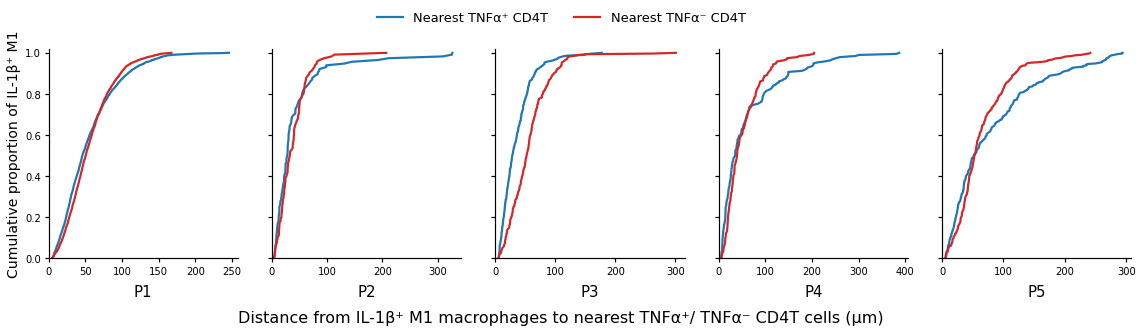


Saved Fig. 1 stats:
C:\Users\Li Chujia\ipynb\typex\Fig4a_IL1bPosM1_centered_TNFaPos_vs_TNFaNeg_CD4T_CDF_stats.csv
Saved Fig. 1 ROI detail:
C:\Users\Li Chujia\ipynb\typex\Fig4a_IL1bPosM1_centered_TNFaPos_vs_TNFaNeg_CD4T_CDF_roi_detail.csv

========== Fig. 1 statistics ==========
                              Comparison Stage             Group_A  \
0  IL1bPos_M1_to_TNFaPos_vs_TNFaNeg_CD4T   All  Nearest TNFα⁺ CD4T   
1  IL1bPos_M1_to_TNFaPos_vs_TNFaNeg_CD4T    P1  Nearest TNFα⁺ CD4T   
2  IL1bPos_M1_to_TNFaPos_vs_TNFaNeg_CD4T    P2  Nearest TNFα⁺ CD4T   
3  IL1bPos_M1_to_TNFaPos_vs_TNFaNeg_CD4T    P3  Nearest TNFα⁺ CD4T   
4  IL1bPos_M1_to_TNFaPos_vs_TNFaNeg_CD4T    P4  Nearest TNFα⁺ CD4T   
5  IL1bPos_M1_to_TNFaPos_vs_TNFaNeg_CD4T    P5  Nearest TNFα⁺ CD4T   

              Group_B   n_A   n_B   median_A   median_B  \
0  Nearest TNFα⁻ CD4T  3544  3544  43.931765  49.820929   
1  Nearest TNFα⁻ CD4T  2610  2610  46.001359  50.577907   
2  Nearest TNFα⁻ CD4T   115   115  27.892651  32.557

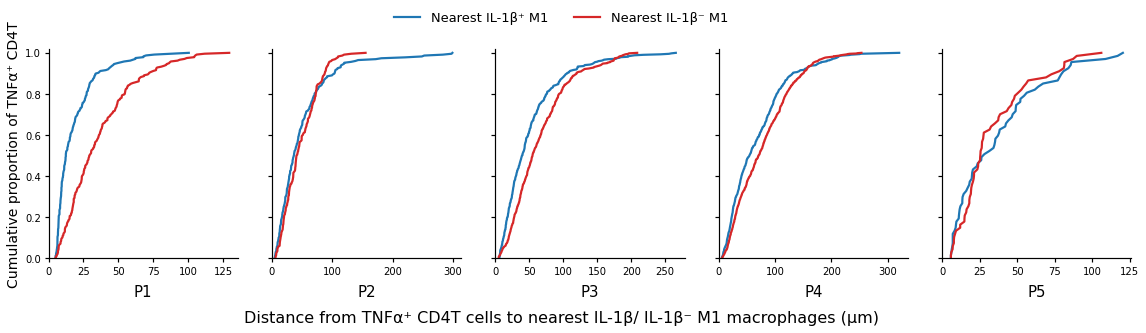


Saved Fig. 2 stats:
C:\Users\Li Chujia\ipynb\typex\Fig4b_TNFaPosCD4T_centered_IL1bPos_vs_IL1bNeg_M1_CDF_stats.csv
Saved Fig. 2 ROI detail:
C:\Users\Li Chujia\ipynb\typex\Fig4b_TNFaPosCD4T_centered_IL1bPos_vs_IL1bNeg_M1_CDF_roi_detail.csv

========== Fig. 2 statistics ==========
                              Comparison Stage            Group_A  \
0  TNFaPos_CD4T_to_IL1bPos_vs_IL1bNeg_M1   All  Nearest IL-1β⁺ M1   
1  TNFaPos_CD4T_to_IL1bPos_vs_IL1bNeg_M1    P1  Nearest IL-1β⁺ M1   
2  TNFaPos_CD4T_to_IL1bPos_vs_IL1bNeg_M1    P2  Nearest IL-1β⁺ M1   
3  TNFaPos_CD4T_to_IL1bPos_vs_IL1bNeg_M1    P3  Nearest IL-1β⁺ M1   
4  TNFaPos_CD4T_to_IL1bPos_vs_IL1bNeg_M1    P4  Nearest IL-1β⁺ M1   
5  TNFaPos_CD4T_to_IL1bPos_vs_IL1bNeg_M1    P5  Nearest IL-1β⁺ M1   

             Group_B   n_A   n_B   median_A   median_B  \
0  Nearest IL-1β⁻ M1  1615  1615  37.013511  50.249378   
1  Nearest IL-1β⁻ M1   238   238  12.369317  29.378140   
2  Nearest IL-1β⁻ M1   228   228  36.372225  41.244332   
3  N

In [6]:
# -*- coding: utf-8 -*-
"""
Two-direction CDF analysis:
1) IL-1β+ M1-centered:
   IL-1β+ M1 -> nearest TNFα+ CD4T vs nearest TNFα- CD4T

2) TNFα+ CD4T-centered:
   TNFα+ CD4T -> nearest IL-1β+ M1 vs nearest IL-1β- M1

Purpose:
To support reciprocal spatial coupling between IL-1β+ M1 macrophages
and TNFα+ CD4T cells.

Author: revised for direct use
"""

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, ks_2samp, wilcoxon


# ============================================================
# 1. Basic configuration
# ============================================================

CSV_PATH = r"C:\Users\Li Chujia\Desktop\cell_annotationV2\annotated_cells_mixed.csv"

OUT_DIR = r"C:\Users\Li Chujia\ipynb\typex"

COL_STAGE    = "标签"       # T001/T002/T004/T005/T006
COL_SLICE    = "子标签"     # ROIxxx
COL_CELLTYPE = "cell_type"
COL_IL1B     = "IL_1b"
COL_TNFA     = "TNFa"

# Stage order: P1 -> P5
PLOT_STAGE_ORDER = ["T005", "T006", "T001", "T002", "T004"]
STAGE_TO_P = {
    "T005": "P1",
    "T006": "P2",
    "T001": "P3",
    "T002": "P4",
    "T004": "P5",
}

# ROI filter
# 当前沿用你原来的设置：仅对 T004 保留 ROI008, ROI009, ROI010
STAGE_SLICE_WHITELIST = {
    "T004": {"ROI008", "ROI009", "ROI010"}
}

# Coordinate column candidates
CAND_X_COLS = ["X", "x", "X_position", "Xpos", "XPos", "CenterX", "center_x", "X_um", "X (um)"]
CAND_Y_COLS = ["Y", "y", "Y_position", "Ypos", "YPos", "CenterY", "center_y", "Y_um", "Y (um)"]


# ============================================================
# 2. Threshold configuration
# ============================================================

# TNFα+ / TNFα- CD4T threshold
# 推荐：在 CD4T 内部计算 TNFα 分位数，更符合“TNFα+ CD4T”的定义
# 如果你想完全沿用原代码的全体细胞阈值，把 TNFA_THRESHOLD_SCOPE 改成 "all"
TNFA_THRESHOLD_SCOPE = "CD4T"   # "CD4T" or "all"
TNFA_Q_LOW  = 0.30
TNFA_Q_HIGH = 0.70

# IL-1β+ / IL-1β- M1 threshold
# 沿用你原代码：在 M1 内部计算 IL-1β 阈值
# 你原代码是 Q_LOW=0.20, Q_HIGH=0.60
# 如果想严格 bottom 30% / top 30%，可改为 0.30 / 0.70
IL1B_Q_LOW  = 0.20
IL1B_Q_HIGH = 0.60


# ============================================================
# 3. Figure configuration
# ============================================================

SAVE_PNG = True
SAVE_PDF = True
SAVE_STATS_CSV = True
SHOW_FIG = True
DPI = 600

FIG_W = 16
FIG_H = 5.2

TOP_MARGIN = 0.80
BOTTOM_MARGIN = 0.24
LEFT_MARGIN = 0.055
RIGHT_MARGIN = 0.995
WSPACE = 0.18

AXIS_LW = 1.2
LINE_W = 2.2

PANEL_STAGE_SIZE    = 15
SHARED_X_LABEL_SIZE = 16
Y_LABEL_SIZE        = 14
X_TICK_SIZE         = 10
Y_TICK_SIZE         = 10
LEGEND_SIZE         = 13

LEGEND_Y = 0.93
LEGEND_NCOL = 2
SHARED_XLABEL_Y = 0.08
PANEL_STAGE_PAD = 8

SHARE_Y = True

# 如需限制 x 轴上限，改成数字，例如 150；不限制设为 None
X_MAX = None

# 统计 proximity 的半径
RADIUS_LIST = [10, 20, 40]

# Colors
COLOR_A = "#1f77b4"
COLOR_B = "#d62728"


# ============================================================
# 4. Utility functions
# ============================================================

def find_first_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def normalize_celltype(x: str) -> str:
    """
    Normalize cell type names into CD4T / CD8T / M1.
    """
    if pd.isna(x):
        return ""

    s = str(x).strip().upper()

    cd4t_aliases = {
        "CD4_T", "CD4 T", "CD4+T", "CD4T",
        "CD4T CELL", "CD4T_CELL", "CD4+ T", "CD4+T CELL"
    }
    cd8t_aliases = {
        "CD8_T", "CD8 T", "CD8+T", "CD8T",
        "CD8T CELL", "CD8T_CELL", "CD8+ T", "CD8+T CELL"
    }
    m1_aliases = {
        "M1", "M1_MACROPHAGE", "M1-LIKE",
        "HUBM1", "M1 LIKE", "M1_MAC", "M1 MACROPHAGE"
    }

    if s in cd4t_aliases:
        return "CD4T"
    if s in cd8t_aliases:
        return "CD8T"
    if s in m1_aliases:
        return "M1"

    s2 = re.sub(r"[^A-Z0-9]", "", s)

    if "CD4" in s2 and "T" in s2:
        return "CD4T"
    if "CD8" in s2 and "T" in s2:
        return "CD8T"
    if s2.startswith("M1"):
        return "M1"

    return s2


def stepwise_cdf(d):
    """
    Given a distance array, return x/y for stepwise CDF.
    """
    d = np.asarray(d, float)
    d = d[np.isfinite(d)]

    if d.size == 0:
        return np.array([]), np.array([])

    d = np.sort(d)
    y = np.arange(1, len(d) + 1) / len(d)

    x = np.concatenate([[d[0]], d])
    y = np.concatenate([[0.0], y])

    return x, y


def set_jcc_style_axes(ax, show_ylabels=True):
    """
    JCC-like figure style: keep only left and bottom spines.
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(AXIS_LW)
    ax.spines["bottom"].set_linewidth(AXIS_LW)

    ax.yaxis.set_ticks_position("left")
    ax.xaxis.set_ticks_position("bottom")

    ax.tick_params(
        axis="x",
        which="both",
        direction="out",
        labelsize=X_TICK_SIZE,
        width=AXIS_LW,
        length=4
    )
    ax.tick_params(
        axis="y",
        which="both",
        direction="out",
        labelsize=Y_TICK_SIZE,
        width=AXIS_LW,
        length=4
    )

    if not show_ylabels:
        ax.tick_params(axis="y", labelleft=False)

    ax.grid(False)


def save_figure(fig, out_dir, out_basename):
    os.makedirs(out_dir, exist_ok=True)

    saved_files = []

    if SAVE_PNG:
        png_path = os.path.join(out_dir, f"{out_basename}.png")
        fig.savefig(png_path, dpi=DPI, bbox_inches="tight", facecolor="white")
        saved_files.append(png_path)

    if SAVE_PDF:
        pdf_path = os.path.join(out_dir, f"{out_basename}.pdf")
        fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
        saved_files.append(pdf_path)

    return saved_files


def apply_stage_slice_filter(sub_stage, stg, col_slice, whitelist_dict):
    keep_set = whitelist_dict.get(stg, None)

    if keep_set is None:
        return sub_stage

    keep_set = set(keep_set)
    return sub_stage[sub_stage[col_slice].isin(keep_set)]


def query_nearest_distance(query_xy, ref_xy):
    """
    Compute nearest-neighbor distance from each query point to reference points.
    """
    if len(query_xy) == 0 or len(ref_xy) == 0:
        return np.array([])

    tree = cKDTree(ref_xy)

    try:
        d, _ = tree.query(query_xy, k=1, workers=-1)
    except TypeError:
        d, _ = tree.query(query_xy, k=1)

    return np.asarray(d, float)


def build_stage_to_two_reference_dists(
    df,
    query_mask,
    ref_a_mask,
    ref_b_mask,
    stages,
    col_stage,
    col_slice,
    col_x,
    col_y,
    whitelist_dict=None,
    require_both_refs=True
):
    """
    For each stage and ROI:
    compute distance from the same query cells to nearest Ref A and nearest Ref B.

    This is important because the two CDF curves will have the same denominator:
    the cumulative proportion of the same query cell population.

    Parameters
    ----------
    query_mask : boolean Series
        The cells being accumulated on the y-axis.
    ref_a_mask : boolean Series
        First reference population.
    ref_b_mask : boolean Series
        Second reference population.
    require_both_refs : bool
        If True, an ROI is used only when query, Ref A, and Ref B all exist.
        This makes the comparison fairer.

    Returns
    -------
    stage_to_a : dict
        stage -> distances from query to Ref A
    stage_to_b : dict
        stage -> distances from query to Ref B
    detail_rows : list
        ROI-level information about used/skipped ROIs.
    """
    stage_to_a = {}
    stage_to_b = {}
    detail_rows = []

    whitelist_dict = whitelist_dict or {}

    for stg in stages:
        sub_stage = df[df[col_stage].astype(str).str.strip() == stg].copy()

        if sub_stage.empty:
            continue

        sub_stage = apply_stage_slice_filter(sub_stage, stg, col_slice, whitelist_dict)

        dists_a_all = []
        dists_b_all = []

        for roi, sub in sub_stage.groupby(col_slice):
            q_xy = sub.loc[query_mask.loc[sub.index], [col_x, col_y]].dropna().to_numpy()
            a_xy = sub.loc[ref_a_mask.loc[sub.index], [col_x, col_y]].dropna().to_numpy()
            b_xy = sub.loc[ref_b_mask.loc[sub.index], [col_x, col_y]].dropna().to_numpy()

            n_q = len(q_xy)
            n_a = len(a_xy)
            n_b = len(b_xy)

            used = True
            reason = "used"

            if n_q == 0:
                used = False
                reason = "no_query"
            elif n_a == 0 and require_both_refs:
                used = False
                reason = "no_ref_a"
            elif n_b == 0 and require_both_refs:
                used = False
                reason = "no_ref_b"
            elif n_a == 0 or n_b == 0:
                used = False
                reason = "missing_one_reference"

            if used:
                d_a = query_nearest_distance(q_xy, a_xy)
                d_b = query_nearest_distance(q_xy, b_xy)

                if len(d_a) > 0 and len(d_b) > 0:
                    dists_a_all.append(d_a)
                    dists_b_all.append(d_b)
                else:
                    used = False
                    reason = "empty_distance_after_query"

            detail_rows.append({
                "Stage_code": stg,
                "Stage": STAGE_TO_P.get(stg, stg),
                "ROI": roi,
                "n_query": n_q,
                "n_ref_a": n_a,
                "n_ref_b": n_b,
                "used": used,
                "reason": reason
            })

        if dists_a_all:
            stage_to_a[stg] = np.concatenate(dists_a_all, axis=0)

        if dists_b_all:
            stage_to_b[stg] = np.concatenate(dists_b_all, axis=0)

    return stage_to_a, stage_to_b, detail_rows


def p_within(d, radius):
    d = np.asarray(d, float)
    d = d[np.isfinite(d)]

    if d.size == 0:
        return np.nan

    return float(np.mean(d <= radius))


def safe_mannwhitneyu(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)

    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if a.size == 0 or b.size == 0:
        return np.nan, np.nan

    try:
        u_stat, p_val = mannwhitneyu(a, b, alternative="two-sided")
        return float(u_stat), float(p_val)
    except Exception:
        return np.nan, np.nan


def safe_ks_2samp(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)

    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if a.size == 0 or b.size == 0:
        return np.nan, np.nan

    try:
        ks_stat, p_val = ks_2samp(a, b, alternative="two-sided")
        return float(ks_stat), float(p_val)
    except Exception:
        return np.nan, np.nan


def safe_wilcoxon_paired(a, b):
    """
    Paired Wilcoxon signed-rank test.
    Here a and b are distances from the same query cells to Ref A and Ref B.

    If Ref A is closer than Ref B, median(a - b) should be negative.
    """
    a = np.asarray(a, float)
    b = np.asarray(b, float)

    valid = np.isfinite(a) & np.isfinite(b)
    a = a[valid]
    b = b[valid]

    if a.size == 0 or b.size == 0 or a.size != b.size:
        return np.nan, np.nan

    diff = a - b

    # If all differences are zero, Wilcoxon is not informative
    if np.allclose(diff, 0):
        return np.nan, np.nan

    try:
        stat, p_val = wilcoxon(a, b, alternative="two-sided")
        return float(stat), float(p_val)
    except Exception:
        return np.nan, np.nan


def summarize_two_distance_sets(stage_to_a, stage_to_b, label_a, label_b, comparison_name):
    """
    Generate statistics table for two distance distributions.
    """
    rows = []

    # All stages combined
    all_a = np.concatenate(list(stage_to_a.values())) if len(stage_to_a) > 0 else np.array([])
    all_b = np.concatenate(list(stage_to_b.values())) if len(stage_to_b) > 0 else np.array([])

    rows.append(
        summarize_one_comparison(
            stage_label="All",
            d_a=all_a,
            d_b=all_b,
            label_a=label_a,
            label_b=label_b,
            comparison_name=comparison_name
        )
    )

    # Each stage
    for stg in PLOT_STAGE_ORDER:
        d_a = stage_to_a.get(stg, np.array([]))
        d_b = stage_to_b.get(stg, np.array([]))

        rows.append(
            summarize_one_comparison(
                stage_label=STAGE_TO_P.get(stg, stg),
                d_a=d_a,
                d_b=d_b,
                label_a=label_a,
                label_b=label_b,
                comparison_name=comparison_name
            )
        )

    return pd.DataFrame(rows)


def summarize_one_comparison(stage_label, d_a, d_b, label_a, label_b, comparison_name):
    d_a = np.asarray(d_a, float)
    d_b = np.asarray(d_b, float)

    d_a = d_a[np.isfinite(d_a)]
    d_b = d_b[np.isfinite(d_b)]

    u_stat, mwu_p = safe_mannwhitneyu(d_a, d_b)
    ks_stat, ks_p = safe_ks_2samp(d_a, d_b)
    w_stat, w_p = safe_wilcoxon_paired(d_a, d_b)

    row = {
        "Comparison": comparison_name,
        "Stage": stage_label,
        "Group_A": label_a,
        "Group_B": label_b,

        "n_A": int(len(d_a)),
        "n_B": int(len(d_b)),

        "median_A": np.nanmedian(d_a) if len(d_a) > 0 else np.nan,
        "median_B": np.nanmedian(d_b) if len(d_b) > 0 else np.nan,
        "delta_median_A_minus_B": (
            np.nanmedian(d_a) - np.nanmedian(d_b)
            if len(d_a) > 0 and len(d_b) > 0 else np.nan
        ),

        "mean_A": np.nanmean(d_a) if len(d_a) > 0 else np.nan,
        "mean_B": np.nanmean(d_b) if len(d_b) > 0 else np.nan,

        "MWU_U": u_stat,
        "MWU_p": mwu_p,

        "KS_D": ks_stat,
        "KS_p": ks_p,

        "Paired_Wilcoxon_stat": w_stat,
        "Paired_Wilcoxon_p": w_p,
    }

    for r in RADIUS_LIST:
        row[f"p_within_{r}um_A"] = p_within(d_a, r)
        row[f"p_within_{r}um_B"] = p_within(d_b, r)
        row[f"delta_p_within_{r}um_A_minus_B"] = p_within(d_a, r) - p_within(d_b, r)

    return row


def plot_stagewise_cdf(
    stage_to_a,
    stage_to_b,
    label_a,
    label_b,
    color_a,
    color_b,
    ylabel,
    shared_xlabel,
    out_basename
):
    """
    Plot 1 x 5 stagewise CDF figure.
    """
    fig, axes = plt.subplots(
        1, 5,
        figsize=(FIG_W, FIG_H),
        sharey=SHARE_Y
    )

    for i, stg in enumerate(PLOT_STAGE_ORDER):
        ax = axes[i]

        d_a = stage_to_a.get(stg, np.array([]))
        d_b = stage_to_b.get(stg, np.array([]))

        xs_a, ys_a = stepwise_cdf(d_a)
        xs_b, ys_b = stepwise_cdf(d_b)

        if xs_a.size > 0:
            ax.plot(xs_a, ys_a, color=color_a, linewidth=LINE_W)

        if xs_b.size > 0:
            ax.plot(xs_b, ys_b, color=color_b, linewidth=LINE_W)

        ax.set_xlabel(
            STAGE_TO_P.get(stg, stg),
            fontsize=PANEL_STAGE_SIZE,
            labelpad=PANEL_STAGE_PAD
        )

        if i == 0:
            ax.set_ylabel(ylabel, fontsize=Y_LABEL_SIZE)
            set_jcc_style_axes(ax, show_ylabels=True)
        else:
            set_jcc_style_axes(ax, show_ylabels=False)

        ax.set_xlim(left=0)

        if X_MAX is not None:
            ax.set_xlim(0, X_MAX)

        ax.set_ylim(0, 1.02)

    fig.text(
        0.5,
        SHARED_XLABEL_Y,
        shared_xlabel,
        ha="center",
        va="center",
        fontsize=SHARED_X_LABEL_SIZE
    )

    legend_handles = [
        Line2D([0], [0], color=color_a, lw=LINE_W, label=label_a),
        Line2D([0], [0], color=color_b, lw=LINE_W, label=label_b),
    ]

    fig.legend(
        handles=legend_handles,
        frameon=False,
        fontsize=LEGEND_SIZE,
        loc="upper center",
        bbox_to_anchor=(0.5, LEGEND_Y),
        ncol=LEGEND_NCOL
    )

    plt.subplots_adjust(
        left=LEFT_MARGIN,
        right=RIGHT_MARGIN,
        bottom=BOTTOM_MARGIN,
        top=TOP_MARGIN,
        wspace=WSPACE
    )

    saved_files = save_figure(fig, OUT_DIR, out_basename)

    print(f"\nSaved figure: {out_basename}")
    for f in saved_files:
        print(f)

    if SHOW_FIG:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# 5. Read and preprocess data
# ============================================================

df = None

for enc in ["utf-8", "gbk", "gb18030", "latin1", "utf-8-sig"]:
    try:
        df = pd.read_csv(CSV_PATH, encoding=enc)
        print(f"Loaded with encoding = {enc}")
        break
    except Exception:
        pass

if df is None:
    raise RuntimeError(f"无法读取文件：{CSV_PATH}")

required_cols = [COL_STAGE, COL_SLICE, COL_CELLTYPE, COL_IL1B, COL_TNFA]

for c in required_cols:
    if c not in df.columns:
        raise KeyError(f"缺少必要列：{c}")

col_x = find_first_col(df, CAND_X_COLS)
col_y = find_first_col(df, CAND_Y_COLS)

if col_x is None or col_y is None:
    raise KeyError(
        f"未找到坐标列。\n"
        f"X 候选列 = {CAND_X_COLS}\n"
        f"Y 候选列 = {CAND_Y_COLS}"
    )

df[COL_STAGE] = df[COL_STAGE].astype(str).str.strip()
df[COL_SLICE] = df[COL_SLICE].astype(str).str.strip()

df[col_x] = pd.to_numeric(df[col_x], errors="coerce")
df[col_y] = pd.to_numeric(df[col_y], errors="coerce")
df[COL_IL1B] = pd.to_numeric(df[COL_IL1B], errors="coerce")
df[COL_TNFA] = pd.to_numeric(df[COL_TNFA], errors="coerce")

df = df.dropna(subset=[col_x, col_y]).copy()

df["_ct_norm"] = df[COL_CELLTYPE].astype(str).map(normalize_celltype)

print("\nDetected coordinate columns:")
print("X:", col_x)
print("Y:", col_y)


# ============================================================
# 6. Define cell masks
# ============================================================

mask_cd4_all = df["_ct_norm"] == "CD4T"
mask_m1_all  = df["_ct_norm"] == "M1"

# TNFα threshold
if TNFA_THRESHOLD_SCOPE.upper() == "CD4T":
    tnfa_base = df.loc[mask_cd4_all, COL_TNFA].dropna()
    tnfa_scope_text = "within CD4T cells"
elif TNFA_THRESHOLD_SCOPE.lower() == "all":
    tnfa_base = df[COL_TNFA].dropna()
    tnfa_scope_text = "within all cells"
else:
    raise ValueError("TNFA_THRESHOLD_SCOPE must be 'CD4T' or 'all'.")

tnfa_q_low = tnfa_base.quantile(TNFA_Q_LOW)
tnfa_q_high = tnfa_base.quantile(TNFA_Q_HIGH)

mask_cd4_tnfa_pos = mask_cd4_all & (df[COL_TNFA] >= tnfa_q_high)
mask_cd4_tnfa_neg = mask_cd4_all & (df[COL_TNFA] <= tnfa_q_low)

# IL-1β threshold within M1
il1b_base = df.loc[mask_m1_all, COL_IL1B].dropna()

il1b_q_low = il1b_base.quantile(IL1B_Q_LOW)
il1b_q_high = il1b_base.quantile(IL1B_Q_HIGH)

mask_m1_il1b_pos = mask_m1_all & (df[COL_IL1B] >= il1b_q_high)
mask_m1_il1b_neg = mask_m1_all & (df[COL_IL1B] <= il1b_q_low)

print("\n========== Thresholds ==========")
print(f"TNFα threshold scope: {tnfa_scope_text}")
print(f"TNFα low  quantile ({TNFA_Q_LOW:.2f})  = {tnfa_q_low:.6g}")
print(f"TNFα high quantile ({TNFA_Q_HIGH:.2f}) = {tnfa_q_high:.6g}")

print("\nIL-1β threshold scope: within M1 macrophages")
print(f"IL-1β low  quantile ({IL1B_Q_LOW:.2f})  = {il1b_q_low:.6g}")
print(f"IL-1β high quantile ({IL1B_Q_HIGH:.2f}) = {il1b_q_high:.6g}")

print("\n========== Cell counts ==========")
print("CD4T total:", int(mask_cd4_all.sum()))
print("TNFα+ CD4T:", int(mask_cd4_tnfa_pos.sum()))
print("TNFα- CD4T:", int(mask_cd4_tnfa_neg.sum()))
print("M1 total:", int(mask_m1_all.sum()))
print("IL-1β+ M1:", int(mask_m1_il1b_pos.sum()))
print("IL-1β- M1:", int(mask_m1_il1b_neg.sum()))


# ============================================================
# 7. Figure 1: IL-1β+ M1-centered CDF
# ============================================================

"""
Fig. 1 question:
Among IL-1β+ M1 macrophages, are they closer to TNFα+ CD4T
or TNFα- CD4T?

Query cells:
    IL-1β+ M1

Reference A:
    TNFα+ CD4T

Reference B:
    TNFα- CD4T

Y-axis:
    Cumulative proportion of IL-1β+ M1 macrophages
"""

fig1_stage_to_a, fig1_stage_to_b, fig1_roi_detail = build_stage_to_two_reference_dists(
    df=df,
    query_mask=mask_m1_il1b_pos,
    ref_a_mask=mask_cd4_tnfa_pos,
    ref_b_mask=mask_cd4_tnfa_neg,
    stages=PLOT_STAGE_ORDER,
    col_stage=COL_STAGE,
    col_slice=COL_SLICE,
    col_x=col_x,
    col_y=col_y,
    whitelist_dict=STAGE_SLICE_WHITELIST,
    require_both_refs=True
)

fig1_label_a = "Nearest TNFα⁺ CD4T"
fig1_label_b = "Nearest TNFα⁻ CD4T"

fig1_basename = "Fig4a_IL1bPosM1_centered_TNFaPos_vs_TNFaNeg_CD4T_CDF"

plot_stagewise_cdf(
    stage_to_a=fig1_stage_to_a,
    stage_to_b=fig1_stage_to_b,
    label_a=fig1_label_a,
    label_b=fig1_label_b,
    color_a=COLOR_A,
    color_b=COLOR_B,
    ylabel="Cumulative proportion of IL-1β⁺ M1",
    shared_xlabel="Distance from IL-1β⁺ M1 macrophages to nearest TNFα⁺/ TNFα⁻ CD4T cells (μm)",
    out_basename=fig1_basename
)

fig1_stats = summarize_two_distance_sets(
    stage_to_a=fig1_stage_to_a,
    stage_to_b=fig1_stage_to_b,
    label_a=fig1_label_a,
    label_b=fig1_label_b,
    comparison_name="IL1bPos_M1_to_TNFaPos_vs_TNFaNeg_CD4T"
)

fig1_roi_detail_df = pd.DataFrame(fig1_roi_detail)

if SAVE_STATS_CSV:
    os.makedirs(OUT_DIR, exist_ok=True)

    fig1_stats_path = os.path.join(OUT_DIR, f"{fig1_basename}_stats.csv")
    fig1_stats.to_csv(fig1_stats_path, index=False, encoding="utf-8-sig")

    fig1_roi_path = os.path.join(OUT_DIR, f"{fig1_basename}_roi_detail.csv")
    fig1_roi_detail_df.to_csv(fig1_roi_path, index=False, encoding="utf-8-sig")

    print("\nSaved Fig. 1 stats:")
    print(fig1_stats_path)
    print("Saved Fig. 1 ROI detail:")
    print(fig1_roi_path)

print("\n========== Fig. 1 statistics ==========")
print(fig1_stats.round(6))


# ============================================================
# 8. Figure 2: TNFα+ CD4T-centered CDF
# ============================================================

"""
Fig. 2 question:
Among TNFα+ CD4T cells, are they closer to IL-1β+ M1
or IL-1β- M1?

Query cells:
    TNFα+ CD4T

Reference A:
    IL-1β+ M1

Reference B:
    IL-1β- M1

Y-axis:
    Cumulative proportion of TNFα+ CD4T cells
"""

fig2_stage_to_a, fig2_stage_to_b, fig2_roi_detail = build_stage_to_two_reference_dists(
    df=df,
    query_mask=mask_cd4_tnfa_pos,
    ref_a_mask=mask_m1_il1b_pos,
    ref_b_mask=mask_m1_il1b_neg,
    stages=PLOT_STAGE_ORDER,
    col_stage=COL_STAGE,
    col_slice=COL_SLICE,
    col_x=col_x,
    col_y=col_y,
    whitelist_dict=STAGE_SLICE_WHITELIST,
    require_both_refs=True
)

fig2_label_a = "Nearest IL-1β⁺ M1"
fig2_label_b = "Nearest IL-1β⁻ M1"

fig2_basename = "Fig4b_TNFaPosCD4T_centered_IL1bPos_vs_IL1bNeg_M1_CDF"

plot_stagewise_cdf(
    stage_to_a=fig2_stage_to_a,
    stage_to_b=fig2_stage_to_b,
    label_a=fig2_label_a,
    label_b=fig2_label_b,
    color_a=COLOR_A,
    color_b=COLOR_B,
    ylabel="Cumulative proportion of TNFα⁺ CD4T",
    shared_xlabel="Distance from TNFα⁺ CD4T cells to nearest IL-1β/ IL-1β⁻ M1 macrophages (μm)",
    out_basename=fig2_basename
)

fig2_stats = summarize_two_distance_sets(
    stage_to_a=fig2_stage_to_a,
    stage_to_b=fig2_stage_to_b,
    label_a=fig2_label_a,
    label_b=fig2_label_b,
    comparison_name="TNFaPos_CD4T_to_IL1bPos_vs_IL1bNeg_M1"
)

fig2_roi_detail_df = pd.DataFrame(fig2_roi_detail)

if SAVE_STATS_CSV:
    os.makedirs(OUT_DIR, exist_ok=True)

    fig2_stats_path = os.path.join(OUT_DIR, f"{fig2_basename}_stats.csv")
    fig2_stats.to_csv(fig2_stats_path, index=False, encoding="utf-8-sig")

    fig2_roi_path = os.path.join(OUT_DIR, f"{fig2_basename}_roi_detail.csv")
    fig2_roi_detail_df.to_csv(fig2_roi_path, index=False, encoding="utf-8-sig")

    print("\nSaved Fig. 2 stats:")
    print(fig2_stats_path)
    print("Saved Fig. 2 ROI detail:")
    print(fig2_roi_path)

print("\n========== Fig. 2 statistics ==========")
print(fig2_stats.round(6))


# ============================================================
# 9. Combined summary table
# ============================================================

combined_stats = pd.concat([fig1_stats, fig2_stats], axis=0, ignore_index=True)

combined_stats_path = os.path.join(
    OUT_DIR,
    "Fig4_two_direction_spatial_coupling_CDF_combined_stats.csv"
)

if SAVE_STATS_CSV:
    combined_stats.to_csv(combined_stats_path, index=False, encoding="utf-8-sig")
    print("\nSaved combined stats:")
    print(combined_stats_path)


# ============================================================
# 10. Automatic interpretation helper
# ============================================================

print("\n========== Interpretation guide ==========")
print("Fig. 1:")
print("If 'Nearest TNFα⁺ CD4T' curve is left-shifted above 'Nearest TNFα⁻ CD4T',")
print("then IL-1β⁺ M1 macrophages are preferentially closer to TNFα⁺ CD4T cells.")

print("\nFig. 2:")
print("If 'Nearest IL-1β⁺ M1' curve is left-shifted above 'Nearest IL-1β⁻ M1',")
print("then TNFα⁺ CD4T cells are preferentially closer to IL-1β⁺ M1 macrophages.")

print("\nCombined conclusion:")
print("If both directions are consistent, the data support reciprocal selective spatial coupling")
print("between IL-1β⁺ M1 macrophages and TNFα⁺ CD4T cells.")

print("\nDONE.")